 # Instalación

In [ ]:
!pip install git+https://github.com/huggingface/transformers
!pip install qwen-vl-utils
!pip install openai
!pip install flash-attn

  Cloning https://github.com/huggingface/transformers to /tmp/pip-req-build-wjjy5_3f
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-wjjy5_3f
  Resolved https://github.com/huggingface/transformers to commit 782a58e6f64cffaf6c8bf3098bfb2cc27f2b116f


In [ ]:
import torch
if torch.cuda.is_available():
    print("GPU está disponible:", torch.cuda.get_device_name(0))
else:
    print("GPU NO está disponible.")

GPU está disponible: Tesla T4


In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct",torch_dtype="auto", device_map="auto")

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

print("Qwen 3B cargado")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen 3B cargado


In [ ]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

prompt = 'Describe the given image', # Ajustar el prompt a las necesidades


# Uso del modelo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df =pd.read_excel("descriptions.xlsx")
df["file_name"] = df["file_name"].str.replace('"', '')
df["qwen_prompt1"] = ""
df["qwen_prompt2"] = ""
df["qwen_prompt3"] = ""
df.head()

,file_name,manual_description_1,manual_description_2,manual_description_3,prompt_1,prompt_2,prompt_3,qwen_prompt1,qwen_prompt2,qwen_prompt3
0,01.jpg,"""A close-up shot of a Chilean 500 pesos coin f...","""A macro photograph focusing on a Chilean 500 ...","""A high-detail macro shot where a Chilean 500-...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
1,02.jpg,"""A straight railway track stretching into the ...","""A ground-level perspective of a single railwa...","""A centered, wide-angle shot looking down a st...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
2,03.jpg,"""A close-up shot of an elderly person's wrinkl...","""A macro photograph focusing on the textured s...","""An intimate close-up capturing the weathered ...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
3,04.jpg,"""A wide shot of a vibrant golden sunset over t...","""A landscape photograph capturing a sunset ove...","""A stunning backlit seascape capturing the eph...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
4,05.jpg,"""A field filled with bright yellow wildflower ...","""A medium-wide shot capturing a dense patch of...","""A vibrant landscape photograph showcasing a d...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,


In [ ]:
#Creamos una funcion auxiliar para describir una imagen dado su prompt

from PIL import Image

def generate_caption_qwen(image_path, prompt_text):

    # Cargar y reducir imagen
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((512, 512))

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": prompt_text,
                },
            ],
        }
    ]

    text = processor.apply_chat_template(messages,tokenize=False, add_generation_prompt=True)

    inputs = processor(text=[text],images=[image], padding=True,return_tensors="pt")

    inputs = inputs.to(model.device)

    generated_ids = model.generate(**inputs,max_new_tokens=100,do_sample=False)

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Extraer solamente la respuesta del asistente
    generated_text_lower = generated_text.lower()

    if "assistant" in generated_text_lower:
        idx = generated_text_lower.rfind("assistant")
        generated_text = generated_text[idx + len("assistant"):]

    generated_text = generated_text.strip()

    return generated_text

In [ ]:
#Ejemplo de uso:
import os
import torch

IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"
row = df.iloc[0]

caption = generate_caption_qwen(os.path.join(IMAGE_DIR, row["file_name"]),row["prompt_1"])

print(caption)

The image shows a close-up of a coin with the denomination "500 Pesos" inscribed on it. The coin appears to be made of metal and has a detailed design, including a wreath around the edge. The background is a textured surface, possibly a piece of paper or fabric, which provides a contrasting backdrop to the coin. The year "2002" is also visible on the coin, indicating its year of issue.


In [ ]:
import os
import torch

IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"

for idx, row in df.iterrows():

    try:

        image_path = os.path.join(IMAGE_DIR, row["file_name"])

        print(f"[{idx+1}/{len(df)}] Procesando {row['file_name']}")

        # Prompt 1
        desc1 = generate_caption_qwen(image_path,row["prompt_1"])

        df.loc[idx, "qwen_prompt1"] = desc1

        # Prompt 2
        desc2 = generate_caption_qwen(image_path,row["prompt_2"])

        df.loc[idx, "qwen_prompt2"] = desc2

        # Prompt 3
        desc3 = generate_caption_qwen(image_path,row["prompt_3"])

        df.loc[idx, "qwen_prompt3"] = desc3

        # Guardado de seguridad
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/qwen_resultados.xlsx", index=False)

        print("Completado")

    except Exception as e:

        print(f"Error en {row['file_name']}: {e}")

        # Guardar lo avanzado igualmente
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/qwen_resultados.xlsx",index=False)

[1/19] Procesando 01.jpg
Completado
[2/19] Procesando 02.jpg
Completado
[3/19] Procesando 03.jpg
Completado
[4/19] Procesando 04.jpg
Completado
[5/19] Procesando 05.jpg
Completado
[6/19] Procesando 06.jpg
Completado
[7/19] Procesando 07.jpg
Completado
[8/19] Procesando 08.jpg
Completado
[9/19] Procesando 09.jpg
Completado
[10/19] Procesando 10.jpg
Completado
[11/19] Procesando 11.jpg
Completado
[12/19] Procesando 12.jpg
Completado
[13/19] Procesando 13.jpg
Completado
[14/19] Procesando 14.jpg
Completado
[15/19] Procesando 15.jpg
Completado
[16/19] Procesando 17.jpg
Completado
[17/19] Procesando 18.jpg
Completado
[18/19] Procesando 19.jpg
Completado
[19/19] Procesando 20.jpg
Completado


modelo se demora 7 minutos con 20 segundos en procesar todas las imagenes, lo que se traduce en 7,3 segundos por imagen

In [ ]:
#Cargamos dataframe con las descripciones generadas por el modelo:
import pandas as pd
df2 = pd.read_excel("/content/drive/MyDrive/Lab_inteligencia/qwen_resultados.xlsx")
df2.head()

,file_name,manual_description_1,manual_description_2,manual_description_3,prompt_1,prompt_2,prompt_3,qwen_prompt1,qwen_prompt2,qwen_prompt3
0,01.jpg,"""A close-up shot of a Chilean 500 pesos coin f...","""A macro photograph focusing on a Chilean 500 ...","""A high-detail macro shot where a Chilean 500-...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image shows a close-up of a coin with the ...,The image shows a close-up view of a coin plac...,The image depicts a close-up view of a coin pl...
1,02.jpg,"""A straight railway track stretching into the ...","""A ground-level perspective of a single railwa...","""A centered, wide-angle shot looking down a st...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image depicts an expansive, arid landscape...","The image depicts a desolate, arid landscape w...","The image depicts a desolate, arid landscape w..."
2,03.jpg,"""A close-up shot of an elderly person's wrinkl...","""A macro photograph focusing on the textured s...","""An intimate close-up capturing the weathered ...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image shows a close-up of a person's hand ...,The image shows a close-up of a person's hand ...,The image depicts a close-up view of a person'...
3,04.jpg,"""A wide shot of a vibrant golden sunset over t...","""A landscape photograph capturing a sunset ove...","""A stunning backlit seascape capturing the eph...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a serene sunset over a body ...,The image depicts a serene sunset scene at a b...,The image depicts a serene sunset scene at a b...
4,05.jpg,"""A field filled with bright yellow wildflower ...","""A medium-wide shot capturing a dense patch of...","""A vibrant landscape photograph showcasing a d...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a vibrant field of yellow fl...,The image depicts a vibrant field of yellow fl...,The image depicts a vibrant field of yellow fl...


ahora instalamos el encoder de embedings

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


from sklearn.metrics.pairwise import cosine_similarity

def semantic_similarity(text1, text2):

    emb1 = embedding_model.encode(text1,convert_to_numpy=True)
    emb2 = embedding_model.encode(text2,convert_to_numpy=True)

    return cosine_similarity([emb1],[emb2])[0][0]

df2["sim_prompt1"] = 0.0
df2["sim_prompt2"] = 0.0
df2["sim_prompt3"] = 0.0



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# calculamos similitudes:

for idx, row in df2.iterrows():

    df2.loc[idx, "sim_prompt1"] = semantic_similarity(row["manual_description_1"], row["qwen_prompt1"])

    df2.loc[idx, "sim_prompt2"] = semantic_similarity(row["manual_description_2"], row["qwen_prompt2"])

    df2.loc[idx, "sim_prompt3"] = semantic_similarity(row["manual_description_3"], row["qwen_prompt3"])

In [ ]:
df2[["file_name","sim_prompt1","sim_prompt2","sim_prompt3"]]

,file_name,sim_prompt1,sim_prompt2,sim_prompt3
0,01.jpg,0.667175,0.769614,0.801260
1,02.jpg,0.675481,0.794595,0.670777
2,03.jpg,0.536345,0.684105,0.687102
3,04.jpg,0.767907,0.809647,0.760855
4,05.jpg,0.676924,0.776988,0.637758
5,06.jpg,0.440946,0.530004,0.552786
6,07.jpg,0.728239,0.689227,0.589965
7,08.jpg,0.586488,0.742248,0.772520
8,09.jpg,0.750554,0.758724,0.625520
9,10.jpg,0.615793,0.674653,0.449441


In [ ]:
print("Similitud promedio por cada columna:")
print("Prompt 1:", df2["sim_prompt1"].mean())
print("Prompt 2:", df2["sim_prompt2"].mean())
print("Prompt 3:", df2["sim_prompt3"].mean())

Similitud promedio por cada columna:
Prompt 1: 0.6790328214043065
Prompt 2: 0.7232248939965901
Prompt 3: 0.6683272342932852


Visualizamos una imagen con su descripcion generada por el modelo y la descripcion ground truth

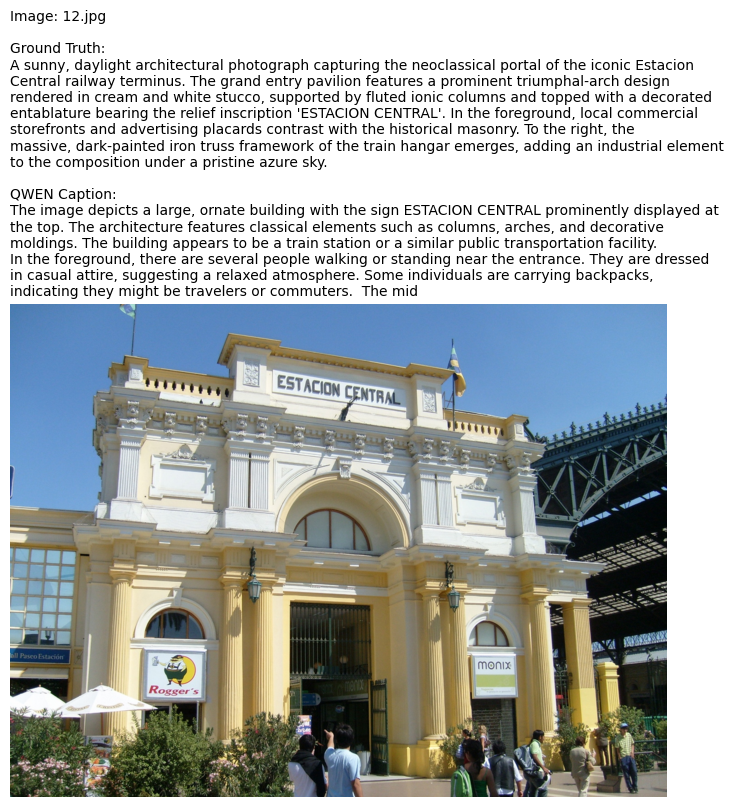

In [ ]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Rutas
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"


def plot_image_with_captions(df,index,prompt_id,model_name,image_dir=IMAGE_DIR, wrap_width=100):
    """
    index: índice de la fila en el DataFrame
    prompt_id: 1, 2 o 3
    model_name: por ejemplo "llama", "qwen" o "smolvlm"
    """

    row = df.iloc[index]

    file_name = row["file_name"]
    image_path = os.path.join(image_dir, file_name)

    manual_col = f"manual_description_{prompt_id}"
    model_col = f"{model_name}_prompt{prompt_id}"

    manual_caption = str(row[manual_col]).replace('"', '').strip()
    model_caption = str(row[model_col]).replace('"', '').strip()

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Image: {file_name}\n\n"
        f"Ground Truth:\n{textwrap.fill(manual_caption, wrap_width)}\n\n"
        f"{model_name.upper()} Caption:\n{textwrap.fill(model_caption, wrap_width)}"
    )

    plt.title(title, fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()



plot_image_with_captions(df2, index=11, prompt_id=3, model_name="qwen")

# OCR

In [ ]:
#Cargamos Data frame con las imagenes de OCR:
import pandas as pd

df =pd.read_excel("descripciones_OCR.xlsx")
df["qwen_prompt1"] = ""
df["qwen_prompt2"] = ""
df["qwen_prompt3"] = ""
df.head()

,file_name,prompt_1,prompt_2,prompt_3,qwen_prompt1,qwen_prompt2,qwen_prompt3
0,20220101_035959.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
1,20230214_122422.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
2,20230430_150424.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
3,20230511_133754.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
4,20230811_151805.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,


In [ ]:
import os
import torch
#Hacemos OCR por cada ejemplo de la base de datos de forma iterativa:
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/OCR"

for idx, row in df.iterrows():

    try:

        image_path = os.path.join(IMAGE_DIR, row["file_name"])

        print(f"[{idx+1}/{len(df)}] Procesando {row['file_name']}")

        # Prompt 1
        desc1 = generate_caption_qwen(image_path,row["prompt_1"])

        df.loc[idx, "qwen_prompt1"] = desc1

        # Prompt 2
        desc2 = generate_caption_qwen(image_path,row["prompt_2"])

        df.loc[idx, "qwen_prompt2"] = desc2

        # Prompt 3
        desc3 = generate_caption_qwen(image_path,row["prompt_3"])

        df.loc[idx, "qwen_prompt3"] = desc3

        # Guardado de seguridad
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/qwen_resultados_OCR.xlsx", index=False)

        print("Completado")

    except Exception as e:

        print(f"Error en {row['file_name']}: {e}")

        # Guardar lo avanzado igualmente
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/qwen_resultados_OCR.xlsx",index=False)

[1/15] Procesando 20220101_035959.jpg
Completado
[2/15] Procesando 20230214_122422.jpg
Completado
[3/15] Procesando 20230430_150424.jpg
Completado
[4/15] Procesando 20230511_133754.jpg
Completado
[5/15] Procesando 20230811_151805.jpg
Completado
[6/15] Procesando 20231108_090334.jpg
Completado
[7/15] Procesando 20240401_124930.jpg
Completado
[8/15] Procesando 20240603_120302.jpg
Completado
[9/15] Procesando 20250331_130243.jpg
Completado
[10/15] Procesando 20250819_074858.jpg
Completado
[11/15] Procesando 20250819_074905.jpg
Completado
[12/15] Procesando 20250908_140611.jpg
Completado
[13/15] Procesando 20250908_154959.jpg
Completado
[14/15] Procesando 20250908_155938.jpg
Completado
[15/15] Procesando 20250908_160638.jpg
Completado


In [ ]:
#Caragamos data frame con las descripciones generadas:

df_ocr = pd.read_excel("/content/drive/MyDrive/Lab_inteligencia/qwen_resultados_OCR.xlsx")
df_ocr.head()

,file_name,prompt_1,prompt_2,prompt_3,qwen_prompt1,qwen_prompt2,qwen_prompt3
0,20220101_035959.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image shows a wall with various signs and ...,The image shows a wall with various signs and ...,The image depicts a wall with various signs an...
1,20230214_122422.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image shows a sign attached to the exterio...,The image shows a sign attached to the exterio...,The image depicts a signboard attached to the ...
2,20230430_150424.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image shows a museum exhibit sign about Sm...,The image shows a museum exhibit sign about Sm...,The image depicts a museum exhibit sign about ...
3,20230511_133754.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image shows a plaque with text, likely an ...",The image shows a plaque with text in Spanish....,The image appears to be a photograph of a hist...
4,20230811_151805.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image appears to be a section of a book or...,The image appears to be a section from a book ...,The image appears to be a section from a book ...


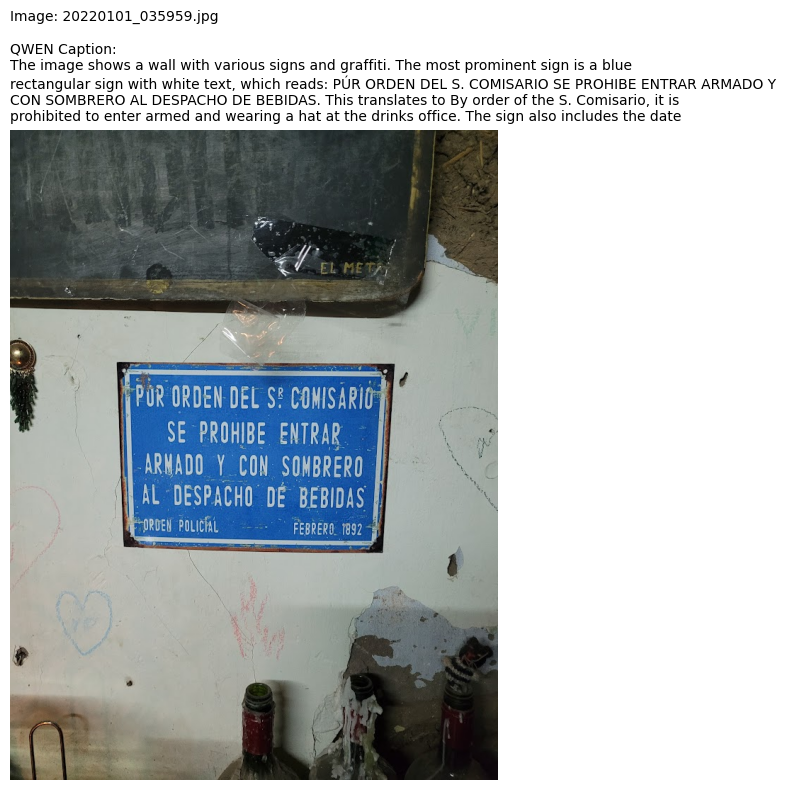

In [ ]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Rutas
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/OCR"


def plot_image_with_captions(df,index,prompt_id,model_name,image_dir=IMAGE_DIR, wrap_width=100):
    """
    index: índice de la fila en el DataFrame
    prompt_id: 1, 2 o 3
    model_name: por ejemplo "llama", "qwen" o "smolvlm"
    """

    row = df.iloc[index]

    file_name = row["file_name"]
    image_path = os.path.join(image_dir, file_name)


    model_col = f"{model_name}_prompt{prompt_id}"
    model_caption = str(row[model_col]).replace('"', '').strip()

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Image: {file_name}\n\n"
        f"{model_name.upper()} Caption:\n{textwrap.fill(model_caption, wrap_width)}"
    )

    plt.title(title, fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()



plot_image_with_captions(df_ocr, index=0, prompt_id=1, model_name="qwen")